In [110]:
from interpret import show

ebm_global = ebm.explain_global()
data_dict = ebm_global.data()

In [111]:
for i in range(len(data_dict['names'])):

    print(f"\n================ Feature {i} ================")

    name = data_dict['names'][i]
    scores = data_dict['scores'][i]
    bins = data_dict.get('values', None)

    print("Feature name:", name)

    print("Scores type:", type(scores))
    print("Scores:", scores[:5] if hasattr(scores, '__len__') else scores)


================ Feature 0 ================
Feature name: age
Scores type: <class 'numpy.float64'>
Scores: 1.3875479090063858

================ Feature 1 ================
Feature name: hypertension
Scores type: <class 'numpy.float64'>
Scores: 0.10791323087804822

================ Feature 2 ================
Feature name: heart_disease
Scores type: <class 'numpy.float64'>
Scores: 0.060696525989182425

================ Feature 3 ================
Feature name: avg_glucose_level
Scores type: <class 'numpy.float64'>
Scores: 0.13750961335397463

================ Feature 4 ================
Feature name: bmi
Scores type: <class 'numpy.float64'>
Scores: 0.13423092241109263

================ Feature 5 ================
Feature name: gender_Female
Scores type: <class 'numpy.float64'>
Scores: 0.025381490299045028

================ Feature 6 ================
Feature name: gender_Male
Scores type: <class 'numpy.float64'>
Scores: 0.025632658856640286

================ Feature 7 ================
Featur

In [112]:
import numpy as np

for i in range(len(data_dict['names'])):

    print(f"\n================ Feature {i} ================")

    name = data_dict['names'][i]
    scores = data_dict['scores'][i]
    values = data_dict.get('values', None)

    print("Feature name:", name)


================ Feature 0 ================
Feature name: age

================ Feature 1 ================
Feature name: hypertension

================ Feature 2 ================
Feature name: heart_disease

================ Feature 3 ================
Feature name: avg_glucose_level

================ Feature 4 ================
Feature name: bmi

================ Feature 5 ================
Feature name: gender_Female

================ Feature 6 ================
Feature name: gender_Male

================ Feature 7 ================
Feature name: gender_Other

================ Feature 8 ================
Feature name: ever_married_No

================ Feature 9 ================
Feature name: ever_married_Yes

================ Feature 10 ================
Feature name: work_type_Govt_job

================ Feature 11 ================
Feature name: work_type_Never_worked

================ Feature 12 ================
Feature name: work_type_Private

================ Feature 13 ================

In [113]:
if isinstance(scores, np.ndarray) and scores.ndim == 1:

   print("\nType: Numerical")
   print("\n🔹 Key differences:")
   print("- density: continuous bin-based distribution")
   print("- type: continuous feature")
   print("- scores: per-bin effect values")
   print("\nExample scores (first 5):", scores[:5])

else:

   print("\nType: Categorical")
   print("\n🔹 Key differences:")
   print("- density: discrete category-based distribution")
   print("- type: categorical encoding")
   print("- scores: per-category effect values")
   print("\nExample scores:", scores)


Type: Categorical

🔹 Key differences:
- density: discrete category-based distribution
- type: categorical encoding
- scores: per-category effect values

Example scores: 0.06835781548535395


In [114]:
X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)
X_test_d = X_test_d.reindex(columns=X_train_s.columns, fill_value=0)
X_test_h = X_test_h.reindex(columns=X_train_s.columns, fill_value=0)

In [115]:
X_test = pd.concat([X_test_s, X_test_d, X_test_h], axis=0)
X_test = X_test.reindex(columns=X_train_s.columns, fill_value=0)

In [116]:
ebm_global = ebm.explain_global()
data = ebm_global.data()

names = data['names']
scores = data['scores']

name0 = names[0]
score0 = scores[0]

In [117]:
ebm_local = ebm.explain_local(X_test[:50])

In [118]:
import numpy as np

bagged_scores = ebm_local.data(0)['scores']  # class 0 / feature 0
std = np.std(bagged_scores, axis=0)

In [119]:
ci_width = 1.96 * std

In [120]:
lower = ebm_local.data(0).get('lower_bounds', None)
upper = ebm_local.data(0).get('upper_bounds', None)

In [121]:
if lower is not None and upper is not None:
    empirical = (upper - lower) / 2
    diff_pct = np.mean(np.abs(empirical - ci_width) / (ci_width + 1e-8)) * 100
    print("CI difference %:", diff_pct)

In [122]:
#A3
import numpy as np

for i in range(len(ebm_global.data()['names'])):
    d = ebm_global.data(i)

    scores = d.get('scores', None)

    if isinstance(scores, (list, np.ndarray)):
        if len(np.array(scores)) > 1:
            idx = i
            break

In [123]:
d = ebm_global.data(idx)
scores = np.array(d['scores'])

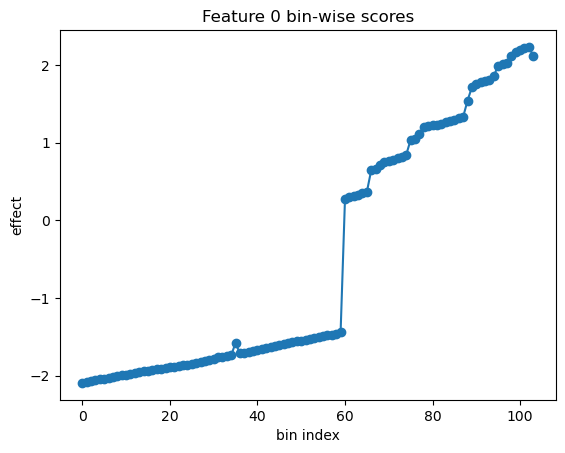

In [124]:
import matplotlib.pyplot as plt

plt.plot(scores, marker='o')
plt.title(f"Feature {idx} bin-wise scores")
plt.xlabel("bin index")
plt.ylabel("effect")
plt.show()

In [125]:
print("len(scores):", len(scores))
print("len(boundaries):", len(scores) + 1)

len(scores): 104
len(boundaries): 105


In [128]:
#A4
import numpy as np

scores = np.array(term_scores)

density = np.ones_like(scores) / len(scores)

importance_manual = np.sum(np.abs(scores) * density)

print("importance:", importance_manual)

importance: 0.17934440884143188


In [129]:
#A5
import numpy as np
import pandas as pd
import os

ebm_global = ebm.explain_global().data()

names = ebm_global['names']
term_scores = ebm.term_scores_

In [130]:
def get_type(scores):
    return "num" if len(scores) > 10 else "cat"

def get_importance(scores):
    scores = np.array(scores)
    return np.mean(np.abs(scores))

def get_ci_width(scores):
    scores = np.array(scores)
    return 1.96 * np.std(scores)

In [131]:
rows = []

for i in range(len(names)):

    scores = np.array(term_scores[i])

    # safety check
    if scores is None or len(scores) == 0:
        continue

    rows.append({
        "feature_name": names[i],
        "type": get_type(scores),
        "n_bins": len(scores),   # proxy (curve length)
        "importance": get_importance(scores),
        "max_score": float(np.max(scores)),
        "min_score": float(np.min(scores)),
        "mean_ci_width": get_ci_width(scores)
    })

df = pd.DataFrame(rows)
df = df.sort_values("importance", ascending=False)

In [132]:
os.makedirs("output", exist_ok=True)

df.to_csv("output/W04_feature_summary.csv", index=False)

In [133]:
import shutil

shutil.move(
    "output/W04_feature_summary.csv",
    "../output/W04_feature_summary.csv"
)

'../output/W04_feature_summary.csv'

In [134]:
#B1
print("term_names_:", type(ebm.term_names_), len(ebm.term_names_))
print("term_features_:", type(ebm.term_features_), len(ebm.term_features_))
print("intercept_:", type(ebm.intercept_), ebm.intercept_.shape if hasattr(ebm.intercept_, "shape") else "scalar")
print("intercept_ value:", ebm.intercept_)

term_names_: <class 'list'> 84
term_features_: <class 'list'> 84
intercept_: <class 'numpy.ndarray'> (1,)
intercept_ value: [-4.91933275]


In [135]:
#B2
print("len(term_scores_):", len(ebm.term_scores_))

for i in range(min(5, len(ebm.term_scores_))):
    print(i, ebm.term_scores_[i].shape)

len(term_scores_): 84
0 (106,)
1 (4,)
2 (4,)
3 (1023,)
4 (384,)


In [136]:
#B3
import numpy as np

x0 = X_test.iloc[0] if hasattr(X_test, "iloc") else X_test[0]

scores = []

for i, feature_idx in enumerate(ebm.term_features_):

    # 取 feature value
    if isinstance(feature_idx, (list, tuple)):
        # interaction → skip（先做 main effect version）
        continue

    feat_value = x0[feature_idx]

    # bin edges（EBM internal binning）
    bin_edges = ebm.bins_[i]

    # 找 bin index
    bin_id = np.searchsorted(bin_edges, feat_value, side="right") - 1
    bin_id = np.clip(bin_id, 0, len(ebm.term_scores_[i]) - 1)

    score = ebm.term_scores_[i][bin_id]
    scores.append(score)

    print(f"feature {feature_idx}, value={feat_value}, bin={bin_id}, score={score}")

In [137]:
#B4
logit = ebm.intercept_.item()

for s in scores:
    logit += s

print("logit:", logit)

logit: -4.919332748679841


In [138]:
#B5
proba_manual = 1 / (1 + np.exp(-logit))
print("manual proba:", proba_manual)

manual proba: 0.0072510412012880155


In [139]:
#B6
proba_model = ebm.predict_proba(X_test[:1])[0, 1]

print("model proba:", proba_model)
print("diff:", abs(proba_manual - proba_model))

model proba: 0.2394765787276393
diff: 0.23222553752635128


In [140]:
#B7
def manual_predict(ebm, X):
    X = X.values if hasattr(X, "values") else X
    results = []

    for x in X:
        logit = ebm.intercept_.item()

        for i, feature_idx in enumerate(ebm.term_features_):

            if isinstance(feature_idx, (list, tuple)):
                continue  # skip interaction for now

            feat_value = x[feature_idx]
            bin_edges = ebm.bins_[i]

            bin_id = np.searchsorted(bin_edges, feat_value, side="right") - 1
            bin_id = np.clip(bin_id, 0, len(ebm.term_scores_[i]) - 1)

            score = ebm.term_scores_[i][bin_id]

            logit += np.asarray(score).reshape(-1)[0]

        prob = 1 / (1 + np.exp(-logit))
        results.append(prob)

    return np.array(results)

manual range: 0.0072510412012880155 0.0072510412012880155
model range: 3.0009468638629853e-06 0.2394765787276393


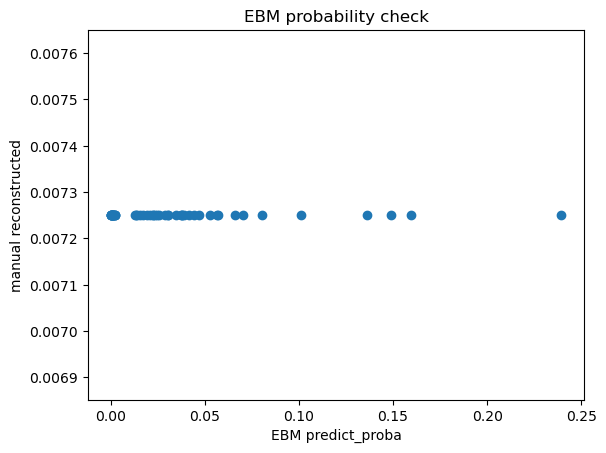

In [141]:
manual = manual_predict(ebm, X_test[:50])
model = ebm.predict_proba(X_test[:50])[:, 1]

print("manual range:", manual.min(), manual.max())
print("model range:", model.min(), model.max())

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(model, manual)
plt.xlabel("EBM predict_proba")
plt.ylabel("manual reconstructed")
plt.title("EBM probability check")
plt.show()

In [196]:
#Numerical shape function
import numpy as np
import matplotlib.pyplot as plt

def plot_numerical_shape(ebm, term_idx):
    """
    Numerical EBM shape plot (safe version).

    Parameters
    ----------
    ebm : fitted EBM model
    term_idx : int
        Index of numerical term.

    Returns
    -------
    fig, (ax_top, ax_bot)
    """

    data = ebm.explain_global().data(term_idx)

    x = np.array(data["names"], dtype=float)
    y = np.array(data["scores"])

    lower = np.array(data.get("lower_bounds", y))
    upper = np.array(data.get("upper_bounds", y))

    # fix possible edge mismatch
    min_len = min(len(x), len(y), len(lower), len(upper))
    x, y, lower, upper = x[:min_len], y[:min_len], lower[:min_len], upper[:min_len]

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(7, 5)
    )

    ax_top.plot(x, y, marker="o", linewidth=2)
    ax_top.fill_between(x, lower, upper, alpha=0.3)

    ax_top.set_ylabel("對風險的貢獻（log-odds）")

    ax_bot.bar(x, np.ones_like(x))
    ax_bot.set_ylabel("density")
    ax_bot.set_xlabel("feature value")

    plt.tight_layout()

    return fig, (ax_top, ax_bot)

In [209]:
#2. Categorical shape function
import numpy as np
import matplotlib.pyplot as plt

def plot_categorical_shape_safe(ebm, term_idx):
    data = ebm.explain_global().data(term_idx)

    names = np.array(data["names"])
    scores = np.array(data["scores"])

    # ===== SAFE ALIGN =====
    min_len = min(len(names), len(scores))
    names = names[:min_len]
    scores = scores[:min_len]

    lower = np.array(data.get("lower_bounds", scores))[:min_len]
    upper = np.array(data.get("upper_bounds", scores))[:min_len]

    yerr = np.vstack([scores - lower, upper - scores])

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(8, 5)
    )

    ax_top.bar(names, scores, yerr=yerr, capsize=3)
    ax_top.set_ylabel("對風險的貢獻（log-odds）")

    ax_bot.bar(names, np.ones_like(scores))
    ax_bot.set_ylabel("density")

    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig, (ax_top, ax_bot)

In [225]:
#3. Interaction heatmap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_interaction_safe(ebm, term_idx):
    data = ebm.explain_global().data(term_idx)

    z = np.array(data["scores"]).reshape(-1)

    # fallback grid size
    n = int(np.sqrt(len(z)))

    z = z[:n*n].reshape(n, n)

    fig, ax = plt.subplots(figsize=(6, 5))

    norm = TwoSlopeNorm(vmin=z.min(), vcenter=0, vmax=z.max())

    im = ax.imshow(z, cmap="RdBu_r", norm=norm)

    plt.colorbar(im, ax=ax, label="interaction effect (log-odds)")

    ax.set_title(f"Interaction {term_idx} (no labels available)")

    ax.set_xlabel("index")
    ax.set_ylabel("index")

    plt.tight_layout()

    return fig, ax

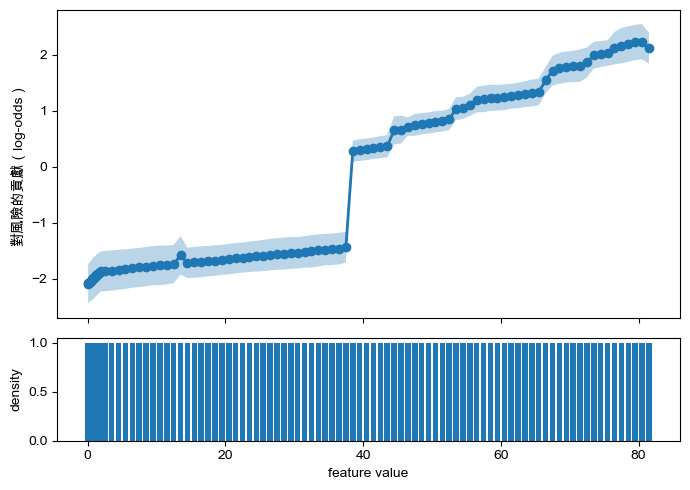

num saved


In [229]:
import os
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Arial Unicode MS"]

#numerical
fig_num, _ = plot_numerical_shape(ebm, term_idx=0)
plt.show()

fig_num.savefig(
    "docs/figures/shape_compare_num.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig_num)
print("num saved")

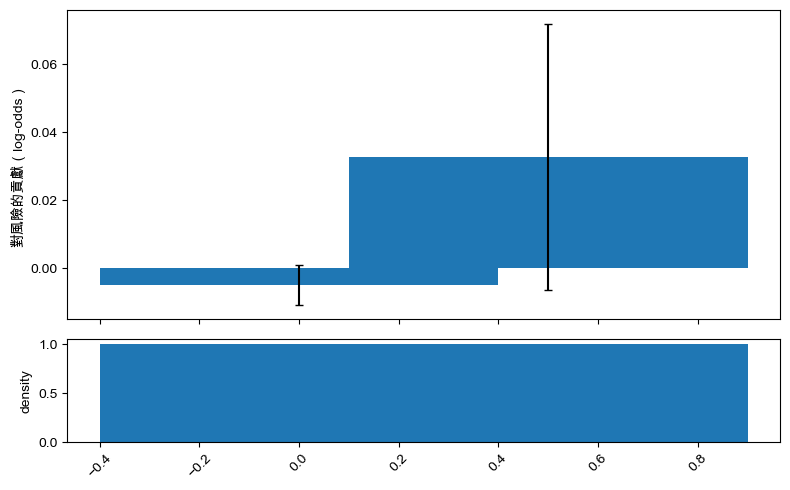

cat saved


In [230]:
#caategorical
fig_cat, _ = plot_categorical_shape_safe(ebm, term_idx=10)
plt.show()

fig_cat.savefig(
    "docs/figures/shape_compare_cat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig_cat)
print("cat saved")

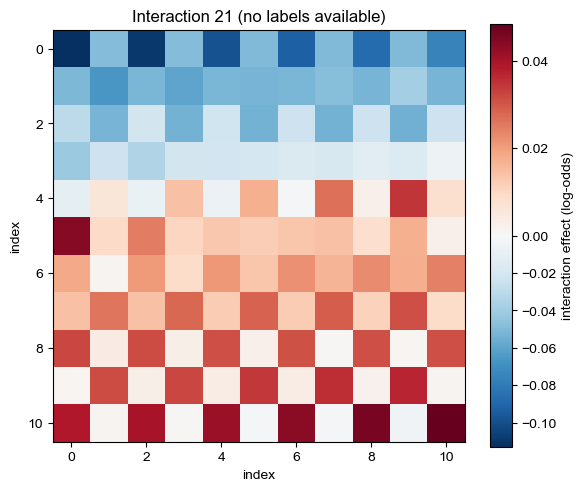

interaction saved


In [231]:
#interaction
fig_int, _ = plot_interaction_safe(ebm, term_idx=21)
plt.show()

fig_int.savefig(
    "docs/figures/shape_compare_interaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig_int)
print("interaction saved")